<a href="https://colab.research.google.com/github/eduardo-illueca/icg-project/blob/main/alba_divide_y_venceras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Load data

In [ ]:
!mkdir /content/RawData/
!wget -q https://zenodo.org/records/4725433/files/01_RawData.zip?download=1 -O /content/RawData/01_RawData.zip
!unzip -qo /content/RawData/01_RawData.zip -d /content/RawData/

!mkdir /content/FilteredData/
!wget -q https://zenodo.org/records/4725433/files/02_FilteredData.zip?download=1 -O /content/FilteredData/02_FilteredData.zip
!unzip -qo /content//FilteredData/02_FilteredData.zip -d /content//FilteredData/

!mkdir /content/Annotations/
!wget -q https://zenodo.org/records/4725433/files/03_ExpertAnnotations.zip?download=1 -O /content/Annotations/02_FilteredData.zip
!unzip -qo /content/Annotations/02_FilteredData.zip -d /content/Annotations/

# Train another model v4 -> more noise


In [ ]:
import numpy as np
import scipy.io as sio
import os
import pandas as pd
from scipy.signal import find_peaks

# ---- Parameters ----
subjects = [str(i) for i in range(1, 25)]
tasks = ['CW', 'BL']
fs = 250  # Hz
segment_len = 200
pre_r = int(0.2 * fs)   # 50 samples
post_r = int(0.6 * fs)  # 150 samples

all_segments = []
all_labels = []

for subject in subjects:
    for task in tasks:
        try:
            # ---- Load files ----
            path_filtered = f'/content/FilteredData/FilteredData_Subject_{subject}_task_{task}.mat'
            path_annotation = f'/content/Annotations/Annotat_Subject_{subject}_task_{task}.mat'

            data_filtered = sio.loadmat(path_filtered)
            annotation = sio.loadmat(path_annotation)

            ecg_filtered = data_filtered['ECG'].squeeze()
            icg_filtered = data_filtered['ICG'].squeeze()
            annotations = annotation['annotPoints']  # shape: [n_annotations, 4]

            # ---- Detect R-peaks ----
            r_peaks, _ = find_peaks(ecg_filtered, distance=int(0.6 * fs), height=np.mean(ecg_filtered))

            for r in r_peaks:
                start = r - pre_r
                end = r + post_r
                if start < 0 or end > len(icg_filtered):
                    continue

                ecg_segment = ecg_filtered[start:end]
                icg_segment = icg_filtered[start:end]
                if len(ecg_segment) != segment_len or len(icg_segment) != segment_len:
                    continue

                segment = np.stack((icg_segment, ecg_segment), axis=-1)  # shape: [200, 2]

                for row in annotations:
                    b, c, x, o = row
                    if start <= b and o <= end:
                        rel_b = b - start
                        rel_x = x - start
                        rel_o = o - start
                        all_segments.append(segment)
                        all_labels.append([rel_b, rel_x, rel_o])
                        break  # avoid duplicate matches for the same R

            print(f"Loaded Subject {subject} Task {task}: {len(r_peaks)} R-peaks")

        except Exception as e:
            print(f"Skipping Subject {subject} Task {task}: {e}")

# ---- Final formatting ----
X = np.array(all_segments)  # [n_samples, 200, 2]
y = np.array(all_labels)    # [n_samples, 3] → B, X, O

# ---- Normalize per channel, per sample ----
X_mean = X.mean(axis=1, keepdims=True)
X_std = X.std(axis=1, keepdims=True) + 1e-8
X = (X - X_mean) / X_std

# ---- One-hot encode labels: classes = B, X, O ----
n_samples = y.shape[0]
n_classes = 3  # Only B, X, O
y_onehot = np.zeros((n_samples, segment_len, n_classes), dtype=np.float32)

for i in range(n_samples):
    for class_idx, t in enumerate(y[i]):  # B=0, X=1, O=2
        if 0 <= t < segment_len:
            y_onehot[i, t, class_idx] = 1.0

# ---- Save everything ----
np.save("X_icg_ecg_segments_bxo.npy", X)           # [n_samples, 200, 2]
np.save("y_icg_labels_bxo.npy", y)                 # [n_samples, 3]
np.save("y_icg_labels_bxo_onehot.npy", y_onehot)   # [n_samples, 200, 3]

# ---- Preview ----
df_preview = pd.DataFrame(y[:10], columns=["B", "X", "O"])
print("\nSample annotation preview (relative to R-aligned segment):")
print(df_preview)


Loaded Subject 1 Task CW: 309 R-peaks
Loaded Subject 1 Task BL: 301 R-peaks
Loaded Subject 2 Task CW: 306 R-peaks
Loaded Subject 2 Task BL: 312 R-peaks
Loaded Subject 3 Task CW: 369 R-peaks
Loaded Subject 3 Task BL: 375 R-peaks
Loaded Subject 4 Task CW: 407 R-peaks
Loaded Subject 4 Task BL: 416 R-peaks
Skipping Subject 5 Task CW: [Errno 2] No such file or directory: '/content/Annotations/Annotat_Subject_5_task_CW.mat'
Loaded Subject 5 Task BL: 404 R-peaks
Loaded Subject 6 Task CW: 339 R-peaks
Loaded Subject 6 Task BL: 355 R-peaks
Loaded Subject 7 Task CW: 326 R-peaks
Loaded Subject 7 Task BL: 342 R-peaks
Loaded Subject 8 Task CW: 389 R-peaks
Loaded Subject 8 Task BL: 387 R-peaks
Loaded Subject 9 Task CW: 408 R-peaks
Loaded Subject 9 Task BL: 400 R-peaks
Loaded Subject 10 Task CW: 318 R-peaks
Loaded Subject 10 Task BL: 314 R-peaks
Loaded Subject 11 Task CW: 430 R-peaks
Loaded Subject 11 Task BL: 391 R-peaks
Loaded Subject 12 Task CW: 339 R-peaks
Loaded Subject 12 Task BL: 359 R-peaks
Lo

In [ ]:
import numpy as np

def augment_batch(X, y, noise_std=0.1, amp_range=(0.9, 1.1), max_shift=2):
    X_aug = np.copy(X)
    y_aug = np.copy(y)

    for i in range(X.shape[0]):
        # --- Gaussian noise ---
        X_aug[i] += np.random.normal(0, noise_std, size=X[i].shape)

        # --- Amplitude scaling ---
        scale = np.random.uniform(*amp_range)
        X_aug[i] *= scale

        # --- Time shift ---
        shift = np.random.randint(-max_shift, max_shift + 1)
        if shift != 0:
            X_aug[i] = np.roll(X_aug[i], shift, axis=0)
            y_aug[i] = np.roll(y_aug[i], shift, axis=0)
            if shift > 0:
                y_aug[i, :shift] = 0
            else:
                y_aug[i, shift:] = 0

    return X_aug, y_aug


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, LSTM, Bidirectional, TimeDistributed, Dense, Dropout

def build_model(input_shape=(200, 2), num_classes=3):
    inputs = Input(shape=input_shape)

    x = Conv1D(64, kernel_size=5, padding='same', activation='relu')(inputs)
    x = Conv1D(128, kernel_size=5, padding='same', activation='relu')(x)

    x = Bidirectional(LSTM(32, return_sequences=True))(x)
    x = Dropout(0.3)(x)  # helps generalization
    x = Bidirectional(LSTM(32, return_sequences=True))(x)

    x = TimeDistributed(Dense(64, activation='relu'))(x)
    outputs = TimeDistributed(Dense(num_classes, activation='softmax'))(x)

    model = Model(inputs, outputs)
    return model

### Training

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

# Load updated B-X-O data
X = np.load("X_icg_ecg_segments_bxo.npy")           # shape: (n_samples, 200, 2)
y = np.load("y_icg_labels_bxo_onehot.npy")          # shape: (n_samples, 200, 3)

# Train/val split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Augment only training data
X_train_aug, y_train_aug = augment_batch(X_train, y_train)

# Build model for 3-class output
model = build_model(input_shape=(200, 2), num_classes=3)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train
history = model.fit(
    X_train_aug, y_train_aug,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.4292 - loss: 0.0121 - val_accuracy: 0.1711 - val_loss: 0.0022
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.2335 - loss: 0.0017 - val_accuracy: 0.3270 - val_loss: 6.7017e-04
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.3623 - loss: 9.5250e-04 - val_accuracy: 0.3326 - val_loss: 6.2014e-04
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.3501 - loss: 6.8794e-04 - val_accuracy: 0.4219 - val_loss: 7.0901e-04
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.3974 - loss: 5.7134e-04 - val_accuracy: 0.4305 - val_loss: 4.6261e-04
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.4416 - loss: 4.5290e-04 - val_accuracy: 0.4330 - val_loss: 5.4463e-04
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.3993 - loss: 3.2825e-04 - val_accuracy: 0.4727 - val_loss: 5.8241e-04
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.4465 - los

## Using the model

In [ ]:
model.save('icg_detector_divide_1.h5')

In [ ]:
def extract_predicted_points(y_pred):
    """
    Extract time indices of predicted B, X, and O points.

    Input:
        y_pred: np.array of shape (n_samples, 200, 3) — softmax outputs
    Returns:
        pred_points: np.array of shape (n_samples, 3) — time indices for B, X, O
    """
    n_samples = y_pred.shape[0]
    pred_points = np.zeros((n_samples, 3), dtype=int)  # B, X, O

    for i in range(3):  # class 0 = B, 1 = X, 2 = O
        pred_points[:, i] = np.argmax(y_pred[:, :, i], axis=1)

    return pred_points

In [ ]:
from tensorflow.keras.models import load_model
model = load_model('icg_detector_divide_1.h5')

y_pred = model.predict(X_val)  # shape: (n_samples, 200, 4)
predicted_points = extract_predicted_points(y_pred)

12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 578ms/step


In [ ]:
import matplotlib.pyplot as plt

def plot_prediction_vs_true(X_sample, y_true_onehot, y_pred_onehot, sample_index=0, fs=250, pre_r=50):
    """
    Visualizes true vs predicted labels on top of ICG signal (for B, X, O only)
    """
    signal = X_sample[sample_index, :, 0]  # ICG signal
    time_steps = np.arange(signal.shape[0])
    time_ms = (time_steps - pre_r) * 1000 / fs

    labels = ["B", "X", "O"]
    colors = ["blue", "green", "red"]

    plt.figure(figsize=(12, 4))
    plt.plot(time_ms, signal, label='ICG signal', color='black', linewidth=1)

    for class_id in range(3):
        true_t = np.argmax(y_true_onehot[sample_index, :, class_id])
        pred_t = np.argmax(y_pred_onehot[sample_index, :, class_id])

        plt.axvline((true_t - pre_r) * 1000 / fs, color=colors[class_id], linestyle='--', label=f'True {labels[class_id]}')
        plt.axvline((pred_t - pre_r) * 1000 / fs, color=colors[class_id], linestyle='-', alpha=0.6, label=f'Pred {labels[class_id]}')

    plt.title(f"Sample {sample_index}: True vs Predicted Characteristic Points (B, X, O)")
    plt.xlabel("Time (ms relative to R-peak)")
    plt.ylabel("ICG amplitude (normalized)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


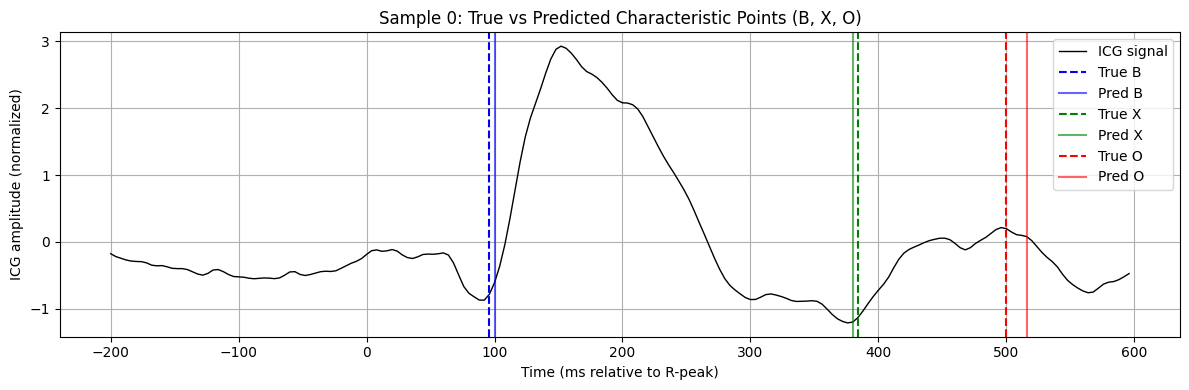

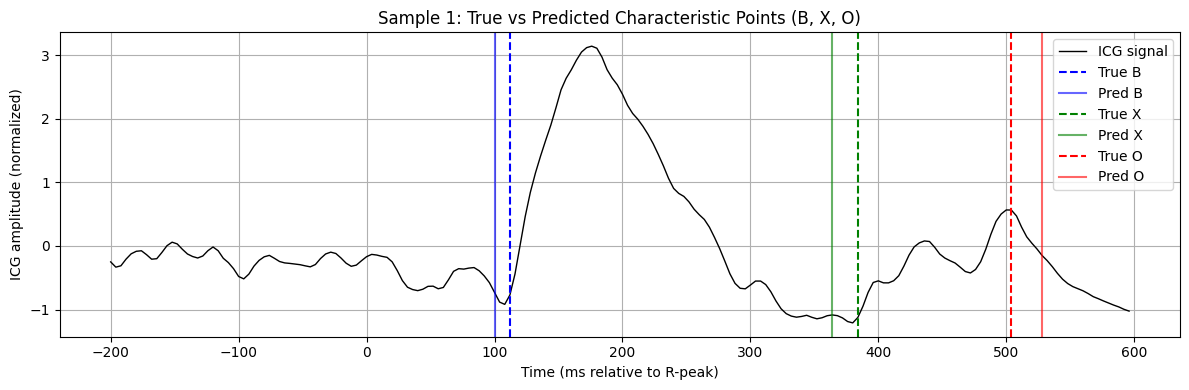

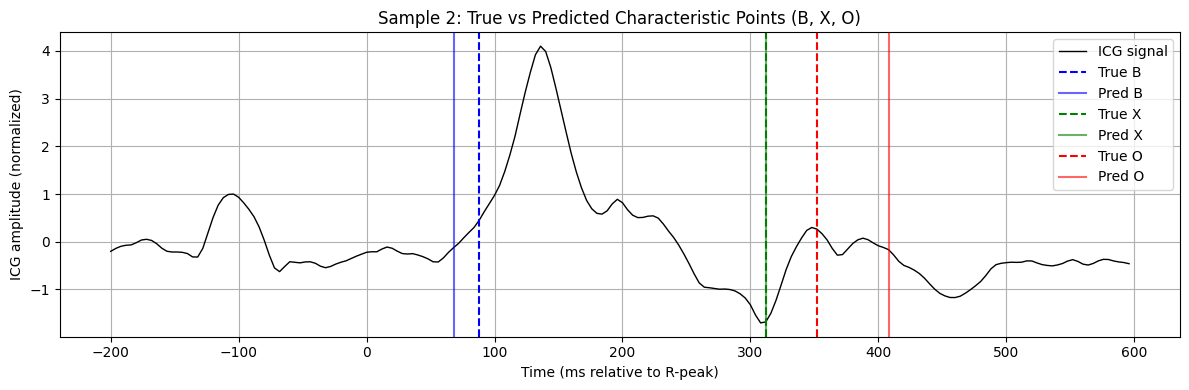

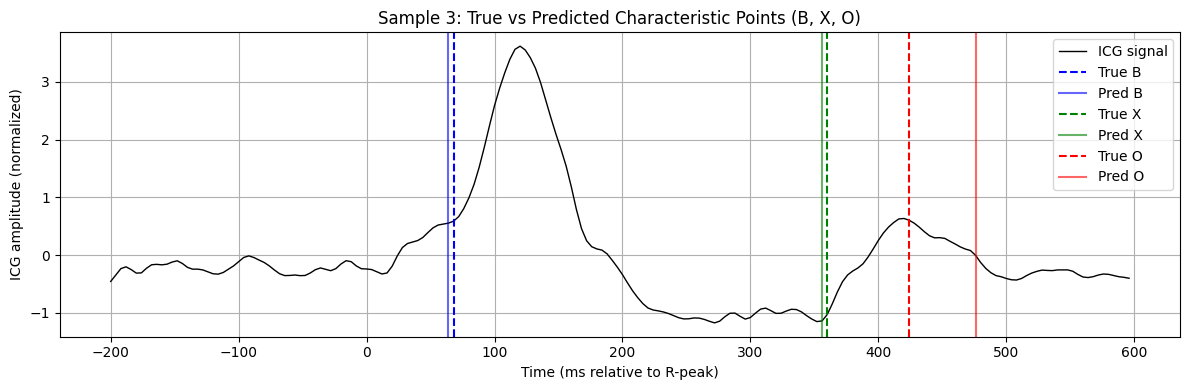

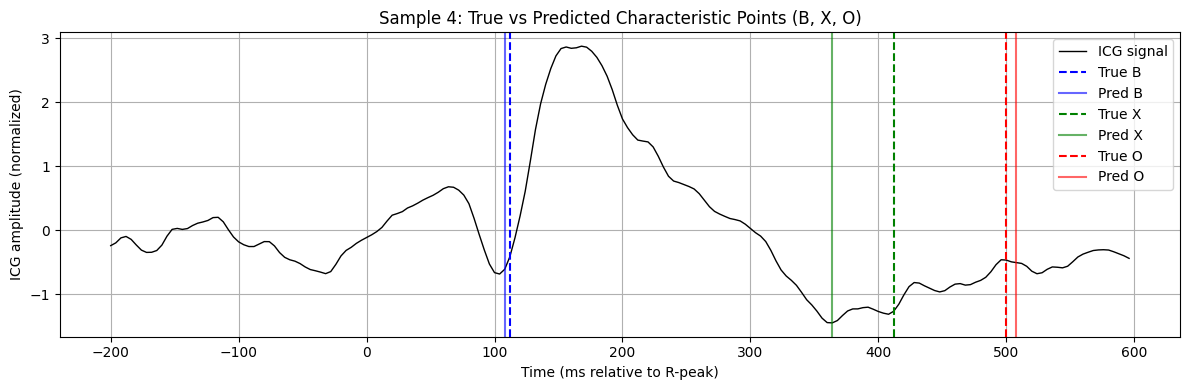

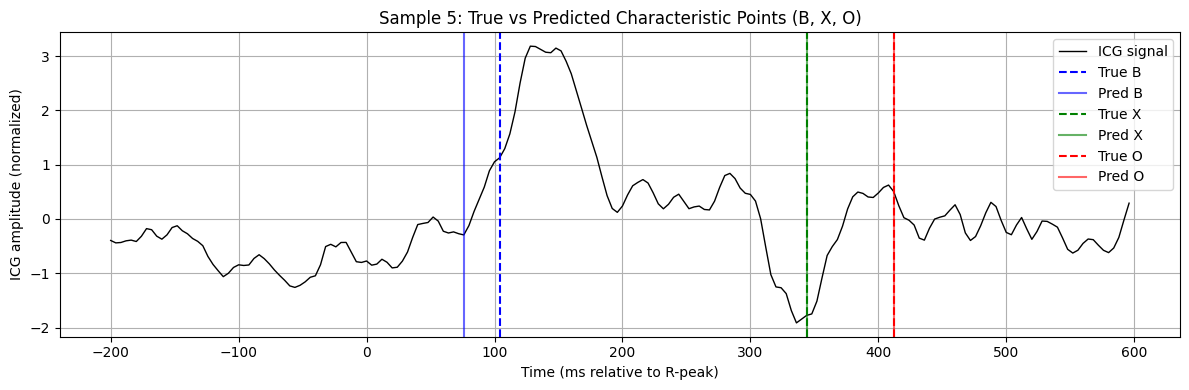

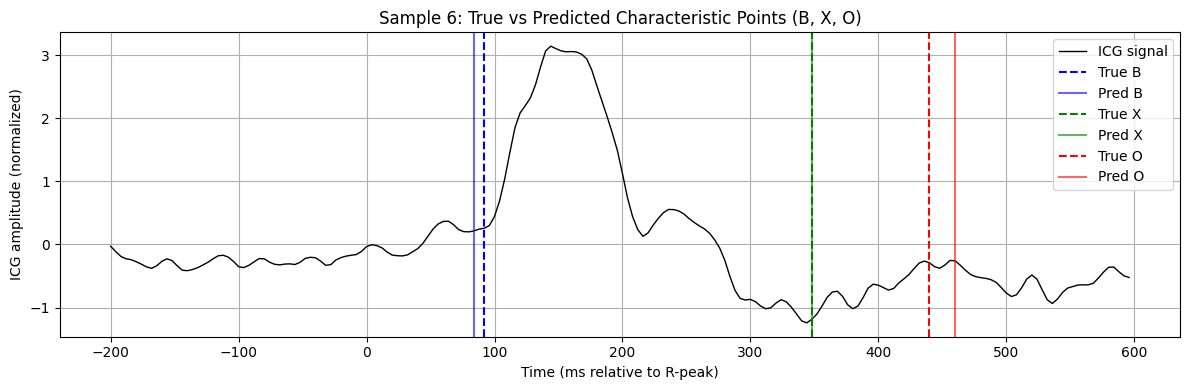

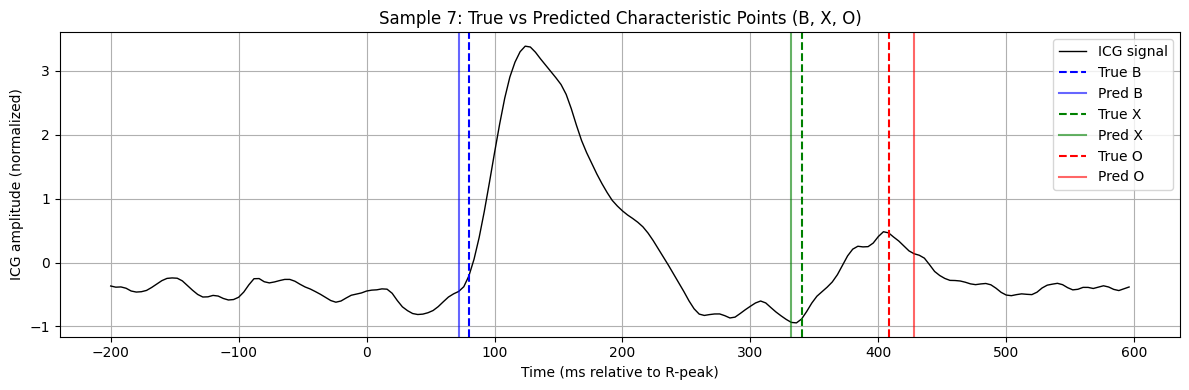

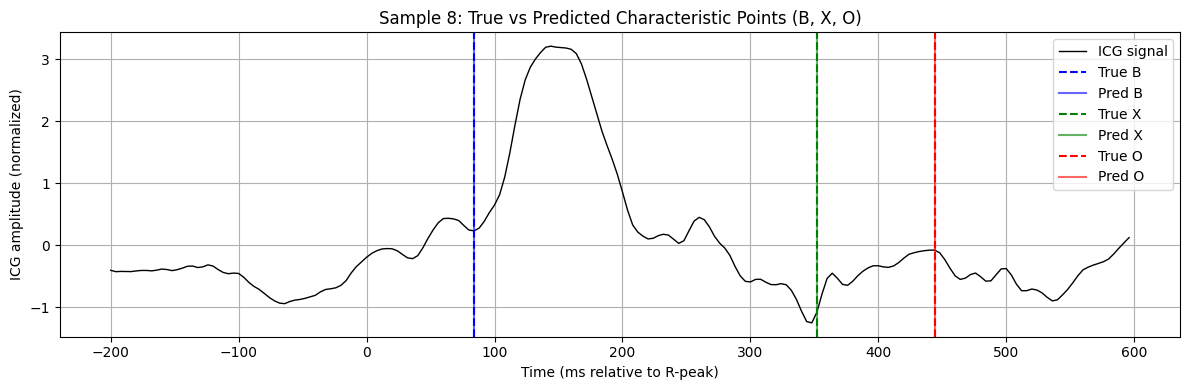

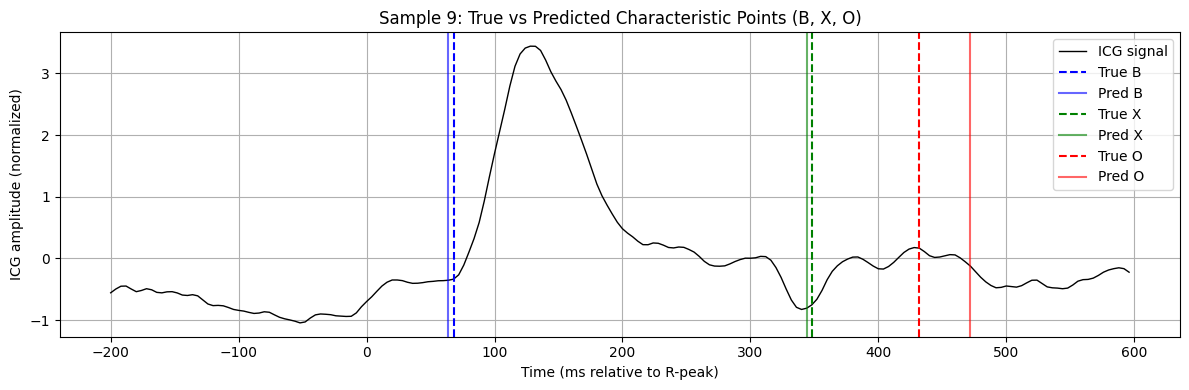

In [ ]:
for i in range(0,10):
  plot_prediction_vs_true(X_val, y_val, y_pred, sample_index=i)


### we evaluate if the model is good

Mean Absolute Error (MAE) measures, on average, how far the model's predictions are from the true values, ignoring the direction.

In [ ]:
import numpy as np

def compute_point_errors(y_true_onehot, y_pred_softmax, fs=250, unit="samples"):
    """
    Computes absolute error for each point type (B, X, O).

    Parameters:
        y_true_onehot: (n_samples, 200, 3) — one-hot encoded true labels
        y_pred_softmax: (n_samples, 200, 3) — softmax predictions
        fs: sampling frequency (Hz)
        unit: 'samples' or 'ms'

    Returns:
        Dictionary of mean absolute error per point and overall mean.
    """
    y_true_idx = np.argmax(y_true_onehot, axis=1)   # (n_samples, 3)
    y_pred_idx = np.argmax(y_pred_softmax, axis=1)  # (n_samples, 3)

    sample_diff = np.abs(y_pred_idx - y_true_idx)

    if unit == "ms":
        diff = (sample_diff * 1000) / fs
    else:
        diff = sample_diff

    labels = ['B', 'X', 'O']
    errors = {lbl: diff[:, i].mean() for i, lbl in enumerate(labels)}
    errors['mean'] = diff.mean()

    return errors


In [ ]:
# Predict
y_pred = model.predict(X_val)  # shape: (n_samples, 200, 3)

# Compute point-wise errors
errors = compute_point_errors(y_val, y_pred, fs=250, unit="samples")

# Display results
for point, err in errors.items():
    print(f"{point} point error: {err:.2f} samples")


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step
B point error: 4.99 samples
X point error: 2.73 samples
O point error: 6.72 samples
mean point error: 4.81 samples


In [ ]:
from google.colab import files
files.download("icg_detector_divide_1.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Trying on unannotated data

Detected 297 R-peaks
Extracted 295 valid segments
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 970ms/step


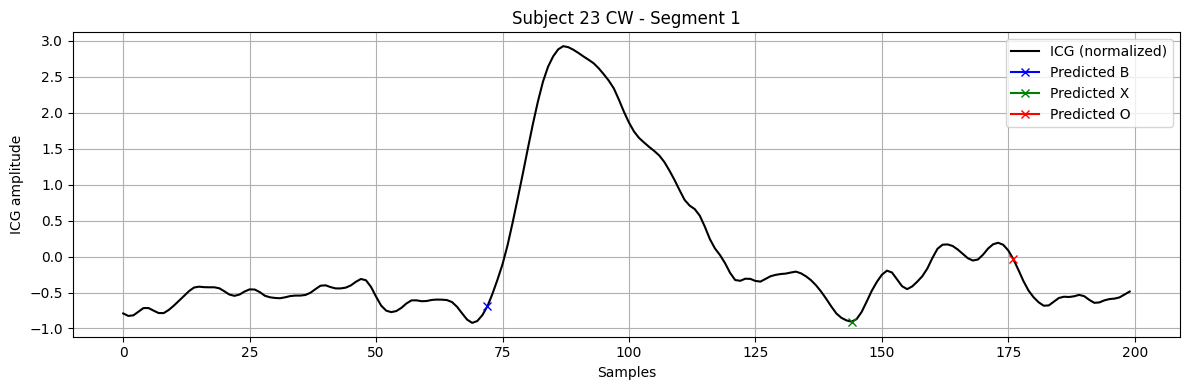

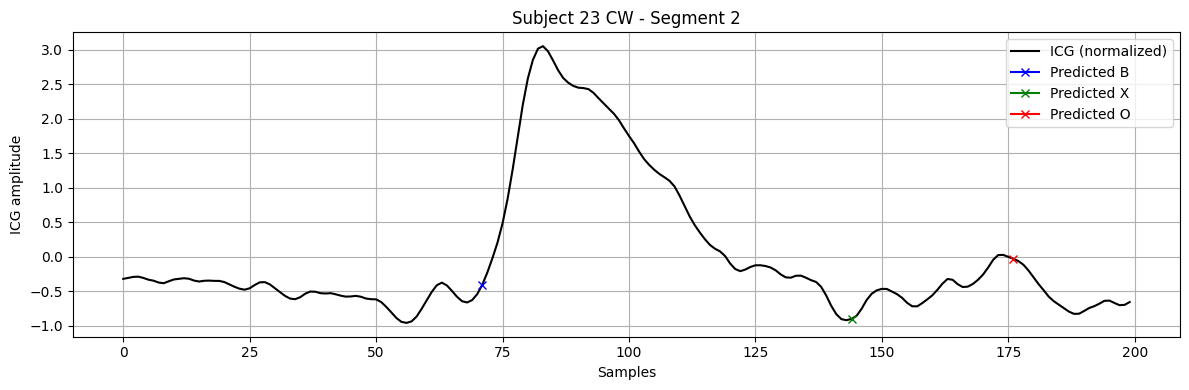

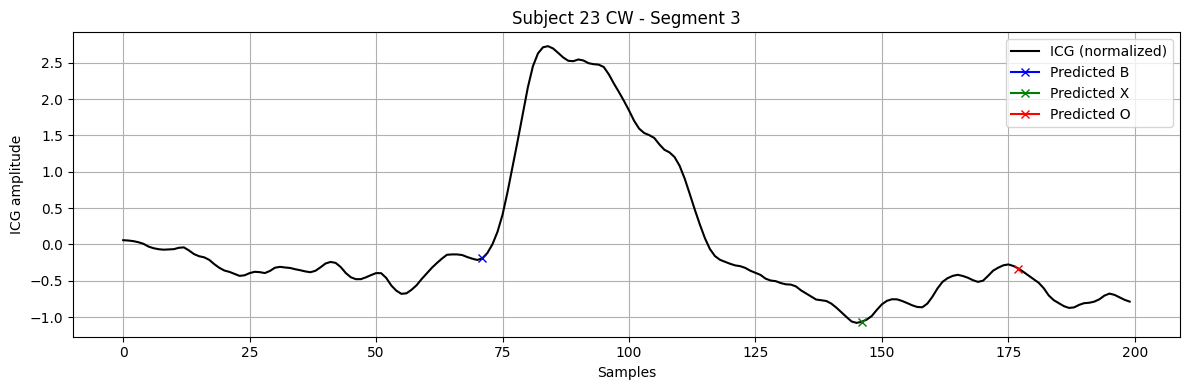

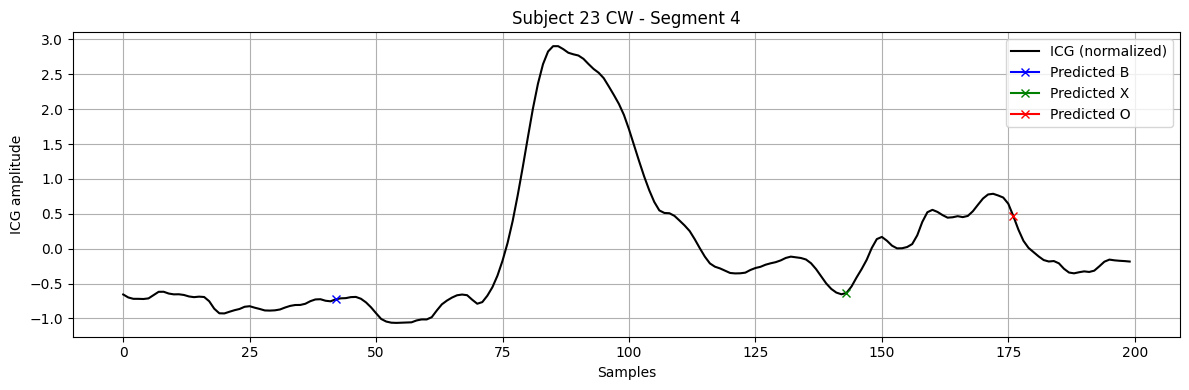

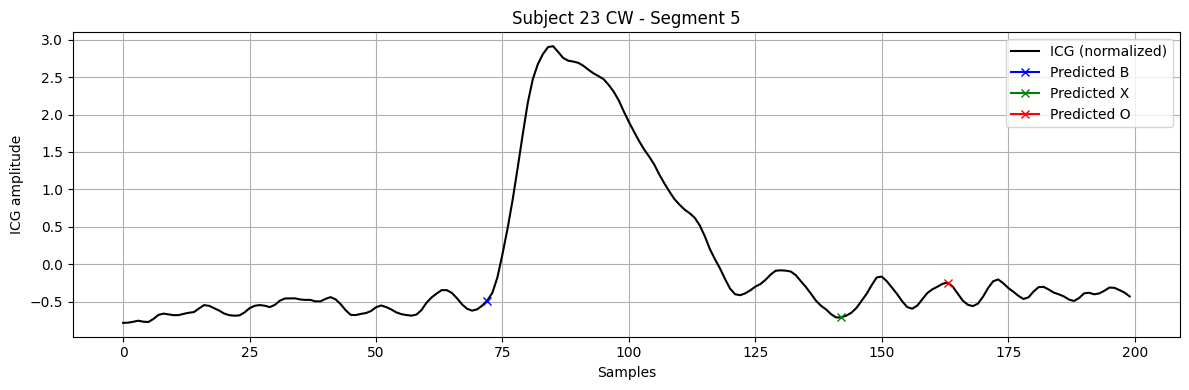

In [ ]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from tensorflow.keras.models import load_model

# ---- Load data ----
subject = '23'
task = 'CW'

data_filtered = sio.loadmat(f'/content/FilteredData/FilteredData_Subject_{subject}_task_{task}.mat')
ecg_filtered = data_filtered['ECG'].squeeze()
icg_filtered = data_filtered['ICG'].squeeze()
fs = int(data_filtered['samplFreq'].squeeze())  # 250 Hz

# ---- R-peak detection ----
r_peaks, _ = find_peaks(ecg_filtered, distance=int(0.6 * fs), height=np.mean(ecg_filtered))
print(f"Detected {len(r_peaks)} R-peaks")

# ---- Segment ICG and ECG ----
pre_r = int(0.2 * fs)
post_r = int(0.6 * fs)
segment_len = pre_r + post_r

segments = []
valid_r_peaks = []

for r in r_peaks:
    start = r - pre_r
    end = r + post_r
    if start >= 0 and end < len(icg_filtered):
        icg_seg = icg_filtered[start:end]
        ecg_seg = ecg_filtered[start:end]
        if len(icg_seg) == segment_len:
            # Normalize per segment
            icg_seg = (icg_seg - np.mean(icg_seg)) / (np.std(icg_seg) + 1e-8)
            ecg_seg = (ecg_seg - np.mean(ecg_seg)) / (np.std(ecg_seg) + 1e-8)

            segment = np.stack((icg_seg, ecg_seg), axis=-1)  # (200, 2)
            segments.append(segment)
            valid_r_peaks.append(r)

print(f"Extracted {len(segments)} valid segments")

X_input = np.array(segments)  # (n_segments, 200, 2)

# ---- Load model and predict ----
model = load_model("icg_detector_divide_1.h5", compile=False)  # 3-class model
y_pred = model.predict(X_input)  # (n, 200, 3)

# ---- Extract predicted points ----
pred_idx = np.argmax(y_pred, axis=1)  # (n, 3), class-wise argmax over time

# ---- Plot ----
labels = ['B', 'X', 'O']
colors = ['blue', 'green', 'red']

for i in range(min(5, len(X_input))):
    signal = X_input[i, :, 0]  # ICG only
    plt.figure(figsize=(12, 4))
    plt.plot(signal, label='ICG (normalized)', color='black')

    for class_id, label, color in zip(range(3), labels, colors):
        idx = pred_idx[i, class_id]
        if 0 <= idx < segment_len:
            plt.plot(idx, signal[idx], marker='x', color=color, label=f'Predicted {label}')

    plt.title(f"Subject {subject} {task} - Segment {i+1}")
    plt.xlabel("Samples")
    plt.ylabel("ICG amplitude")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## C point detection